<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Visual-Recognition/blob/master/LAB_1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A. Intro: ConvNet on CIFAR10
Use PyTorch, start with a CPU, switch to GPU if it gets slow.

Implement a simple convolutional neural network for classifying the CIFAR10 dataset (32×32 RGB images, 10 classes).
- Use a train, val, test split of 3k, 3k, 3k images respectively.
- Train the neural network for ~30 epochs with the AdamW optimizer and a batch size of 64.
- Prevent overfitting using a) dropout and b) data augmentation.
- Add test-time augmentations (TTA).

In [ ]:
import random
import time
from collections.abc import Callable
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import PIL.Image
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, Subset
from torchvision.transforms import v2
from tqdm import tqdm

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

# Check for CUDA / MPS (Apple) / XPU (Intel) / ... (not XLA (Google TPUs), though).
device = torch.accelerator.current_accelerator(True) or torch.device("cpu")
print(device)

### Datasets

In [ ]:
dataset_path = Path("./data/CIFAR10/")
dataset_path.mkdir(parents=True, exist_ok=True)

image_transform = None # TODO


train_dataset = torchvision.datasets.CIFAR10(
    dataset_path, train=True, download=True, transform=image_transform
)
val_dataset = torchvision.datasets.CIFAR10(
    dataset_path, train=True, download=True, transform=image_transform
)
test_dataset = torchvision.datasets.CIFAR10(
    dataset_path, train=False, download=True, transform=image_transform
)
classes = train_dataset.classes
print("Classes:", classes)
print("Original lengths:", len(train_dataset), len(val_dataset), len(test_dataset))

In [ ]:
image, label = train_dataset[0]
print("Image shape:", image.shape, "dtype:", image.dtype)
print("Label type:", type(label))

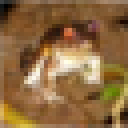

'frog'

In [ ]:
to_pil_image = lambda x: x # TODO

display(to_pil_image(image), classes[label])

In [ ]:
# TODO limit to 3k each.
print("New lengths:", len(train_dataset), len(val_dataset), len(test_dataset))

New lengths: 3000 3000 3000


### Dataloaders

In [ ]:
pin_memory = device.type == "cuda"
train_loader = DataLoader(
    train_dataset, batch_size=64, shuffle=True, num_workers=0, pin_memory=pin_memory
)
val_loader = DataLoader(
    val_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=pin_memory
)
test_loader = DataLoader(
    test_dataset, batch_size=64, shuffle=False, num_workers=0, pin_memory=pin_memory
)

In [ ]:
# Get some random training batch.
image_batch, label_batch = next(iter(train_loader))

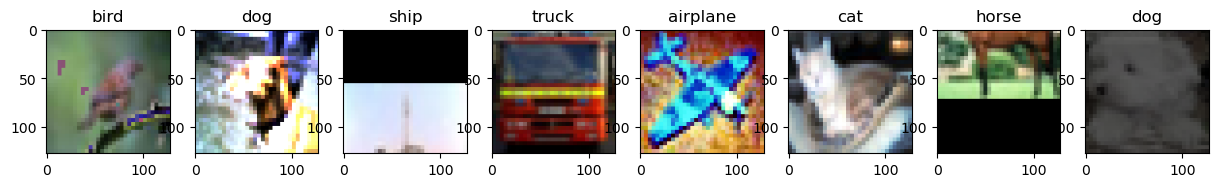

In [ ]:
def show_images(images: torch.Tensor, labels: list[int], limit: int = 8) -> None:
    # TODO
    pass


show_images(image_batch, label_batch)

### Model
Start with: conv 32, conv 64, conv 128 (all with kernel size 3x3, stride 2 and padding 1), ReLU activations, a hidden linear layer 40 with relu, and linear output

In [ ]:
C, H, W = image.shape  # 3, 32, 32
print(C, H, W)

3 32 32


In [ ]:
class Net(nn.Module):
    def __init__(self, num_classes: int = 10) -> None:
        super().__init__()
        # TODO

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO
        raise NotImplementedError()

In [ ]:
class NetWithTTA(nn.Module):
    """Wrapper that applies test-time augmentation (TTA) to a model."""

    def __init__(self, net: Net, repeats: int = 3) -> None:
        super().__init__()
        self.net = net
        self.repeats = repeats
        # TODO

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO
        raise NotImplementedError()


### Training
Start TensorBoard (at the end of this notebook) before running the training.

In [ ]:
from torch.utils.tensorboard import SummaryWriter

global_step = 0


def evaluate(net: nn.Module, dataloader: DataLoader) -> tuple[float, float]:
    """Return (loss, accuracy)."""
    net.eval()
    correct, total_loss, total = 0, 0.0, 0
    with torch.no_grad():
        for image, label in tqdm(dataloader, "Evaluate"):
            image, label = image.to(device), label.to(device)
            logits = net(image)
            loss = nn.CrossEntropyLoss(reduction="sum")(logits, label)
            predicted = logits.argmax(dim=1)
            correct += (predicted == label).sum().item()
            total_loss += loss.item()
            total += label.size(0)
    return (
        total_loss / total,
        correct / total,
    )


def train_epoch(
    net: nn.Module,
    train_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    writer: SummaryWriter,
    desc: str,
) -> None:
    global global_step
    net.train()
    for image, label in tqdm(train_loader, desc):
        image, label = image.to(device), label.to(device)
        optimizer.zero_grad()
        logits = net(image)
        loss = nn.CrossEntropyLoss()(logits, label)
        loss.backward()
        optimizer.step()
        writer.add_scalar("train/loss", loss.item(), global_step)
        global_step += 1


def train(
    net: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int,
    name: str,
) -> None:
    global global_step
    global_step = 0
    writer = SummaryWriter(log_dir=f"runs/{name}_{time.strftime('%H%M')}")

    optimizer = torch.optim.AdamW(net.parameters(), lr=1e-3, weight_decay=1e-4)

    for epoch in range(epochs):
        train_epoch(net, train_loader, optimizer, writer, f"Epoch {epoch + 1}/{epochs}")
        val_loss, val_acc = evaluate(net, val_loader)
        writer.add_scalar("val/loss", val_loss, global_step)
        writer.add_scalar("val/accuracy", val_acc, global_step)

In [ ]:
net = Net().to(device)
net = NetWithTTA(net)
train(net, train_loader, val_loader, epochs=40, name="basic")

In [ ]:
checkpoint_path = Path("./cifar_net.pth")
torch.save(net.state_dict(), checkpoint_path)

In [ ]:
net = Net().to(device)
# net = NetWithTTA(Net()).to(device)
net.load_state_dict(torch.load(checkpoint_path, map_location=device))

In [ ]:
train_loss, train_acc = evaluate(net, train_loader)
val_loss, val_acc = evaluate(net, val_loader)
test_loss, test_acc = evaluate(net, test_loader)
print(f"accuracy on train: {train_acc:.1%}, val: {val_acc:.1%}, test: {test_acc:.1%}")

### TensorBoard

In [ ]:
%load_ext tensorboard
# Sometimes you might need to run this cell twice.
%tensorboard --logdir runs